# step by step dataframe inspection
plots and understandings for steps.csv

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

In [25]:
def plot_box(df, y_col, x_col="ground_type"):
    fig = px.box(
        df,
        x=x_col,
        y=y_col,
        color=x_col,
        points="all",
        title=f"{y_col} by {x_col}"
    )
    fig.show()

def plot_hist(df, x_col, color_col="ground_type"):
    fig = px.histogram(
        df,
        x=x_col,
        color=color_col,
        barmode="overlay",
        marginal="box",
        title=f"{x_col} distribution by {color_col}"
    )
    fig.update_traces(opacity=0.6)
    fig.show()

def plot_scatter(df, x_col, y_col, color_col="ground_type"):
    fig = px.scatter(
        df,
        x=x_col,
        y=y_col,
        color=color_col,
        hover_data=df.columns,
        title=f"{x_col} vs {y_col}"
    )
    fig.show()

In [3]:
# load
df = pd.read_csv("step_level_data.csv")

# quick overview
print(df.shape)
print(df['ground_type'].value_counts())
print(df.head())

(348, 62)
ground_type
asphalt    123
grass      119
brick      106
Name: count, dtype: int64
  ground_type  sole_id  n_samples  duration_s  total_pressure_mean  \
0     asphalt        1         11       0.160          4623.272727   
1     asphalt        1          9       0.128          4822.333333   
2     asphalt        1         44       0.688          4796.840909   
3     asphalt        1         16       0.240          4706.625000   
4     asphalt        1         20       0.304          4698.750000   

   total_pressure_max  total_pressure_std  total_pressure_auc  \
0              4835.0          174.098766             50856.0   
1              5946.0          668.241972             43401.0   
2              5339.0          288.311696            211061.0   
3              5121.0          257.606744             75306.0   
4              4941.0          252.414317             93975.0   

   pressure_01_mean  pressure_01_max  ...  accel_z_std   gyro_x_mean  \
0        561.181818    

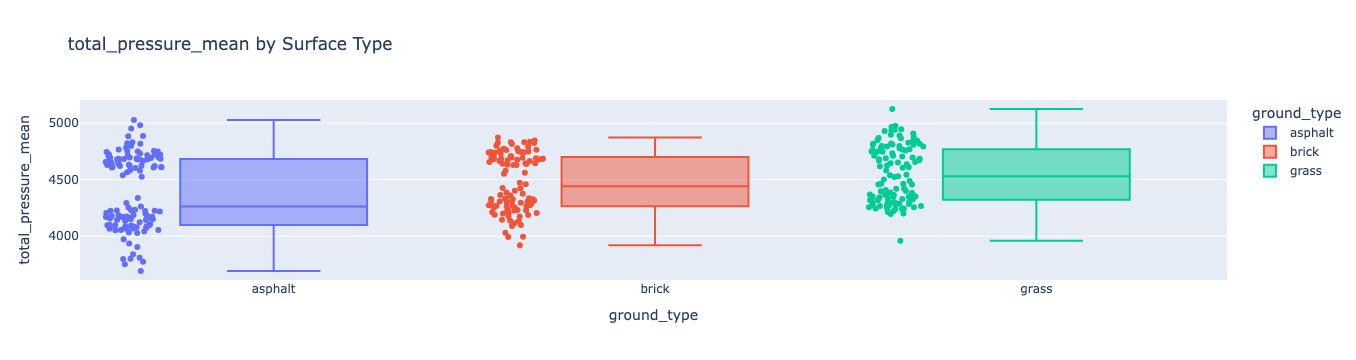

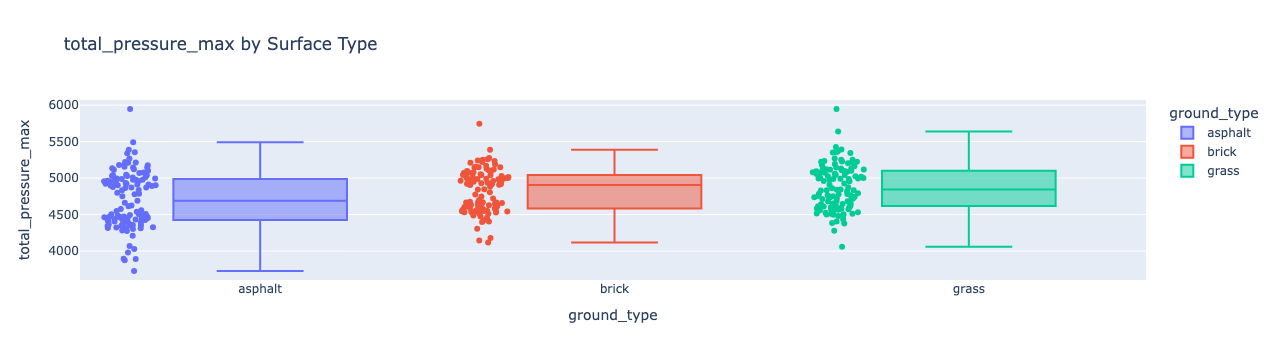

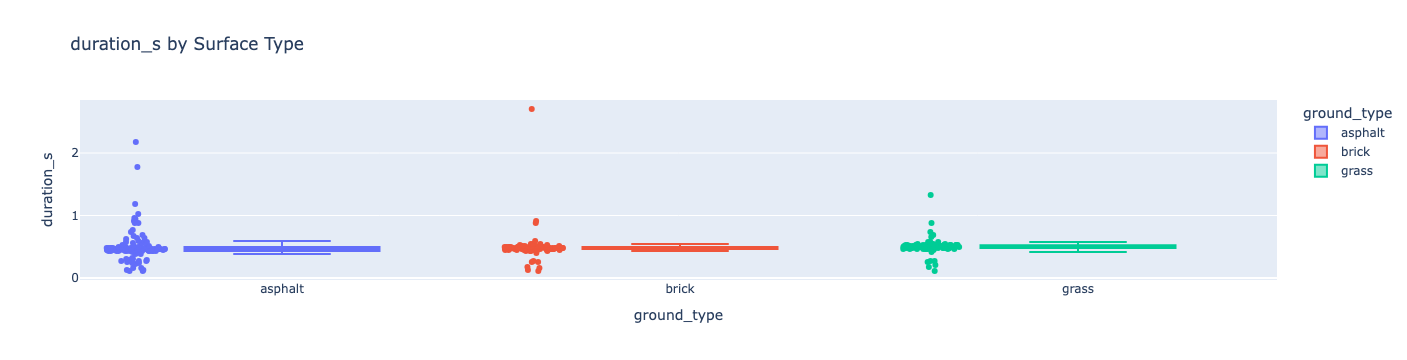

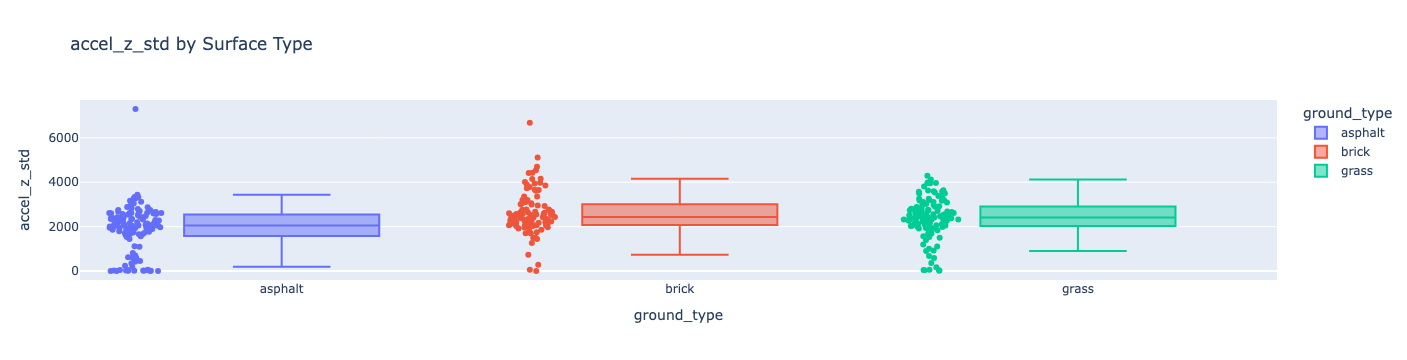

In [11]:
fig = px.box(
    df,
    x="ground_type",
    y="total_pressure_auc",
    color="ground_type",
    title="Total Pressure AUC by Surface Type",
    points="all",   # shows individual steps too
    hover_data=df.columns
)

fig.update_layout(
    xaxis_title="Surface Type",
    yaxis_title="Total Pressure AUC"
)

features = [
    "total_pressure_mean",
    "total_pressure_max",
    "duration_s",
    "accel_z_std"
]

for feature in features:
    fig = px.box(
        df,
        x="ground_type",
        y=feature,
        color="ground_type",
        title=f"{feature} by Surface Type",
        points="all"
    )
    fig.show()

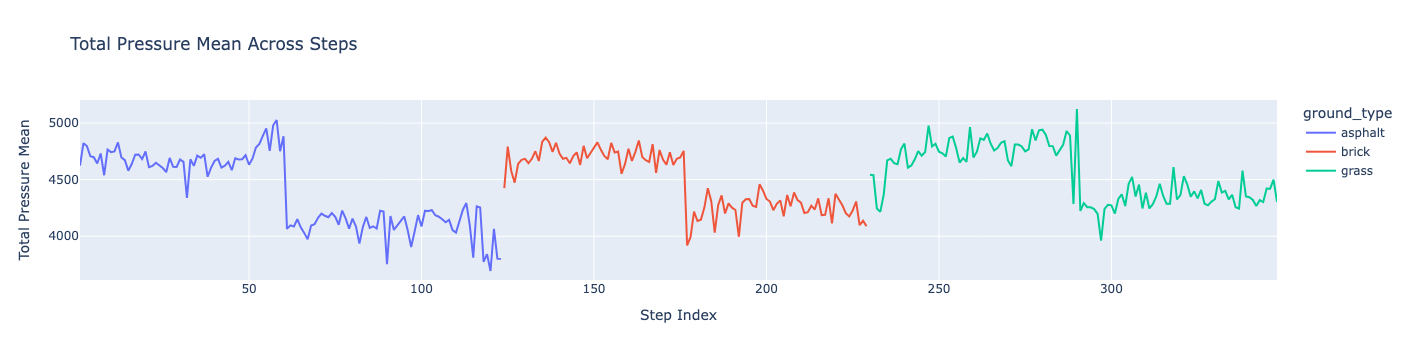

In [12]:
df = df.copy()
df["step_index"] = range(1, len(df) + 1)

fig = px.line(
    df,
    x="step_index",
    y="total_pressure_mean",
    color="ground_type",
    title="Total Pressure Mean Across Steps",
    hover_data=df.columns
)

fig.update_layout(
    xaxis_title="Step Index",
    yaxis_title="Total Pressure Mean"
)

fig.show()

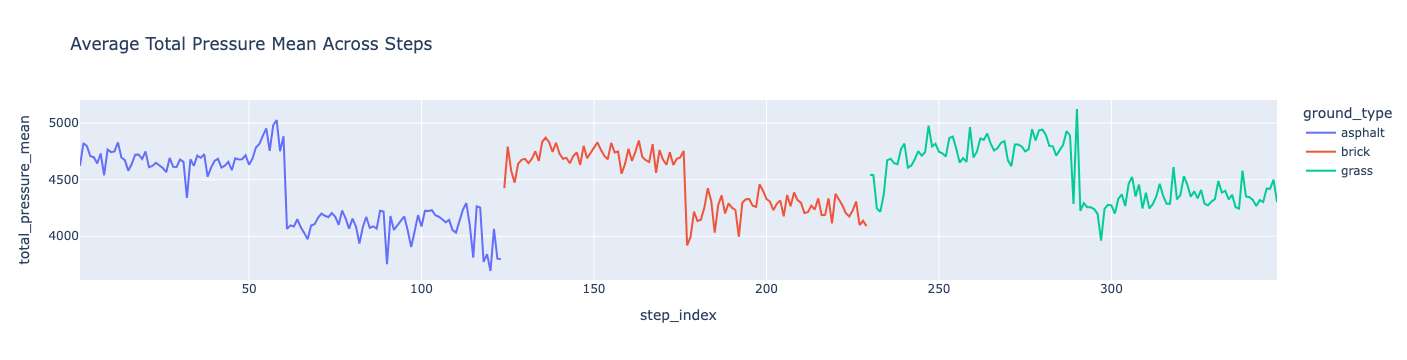

In [14]:
avg_by_surface = (
    df.groupby(["ground_type", "step_index"], as_index=False)["total_pressure_mean"]
    .mean()
)

fig = px.line(
    avg_by_surface,
    x="step_index",
    y="total_pressure_mean",
    color="ground_type",
    title="Average Total Pressure Mean Across Steps"
)

fig.show()

['total_pressure_mean', 'pressure_01_mean', 'pressure_02_mean', 'pressure_03_mean', 'pressure_04_mean', 'pressure_05_mean', 'pressure_06_mean', 'pressure_07_mean', 'pressure_08_mean', 'pressure_09_mean', 'pressure_10_mean', 'pressure_11_mean', 'pressure_12_mean']


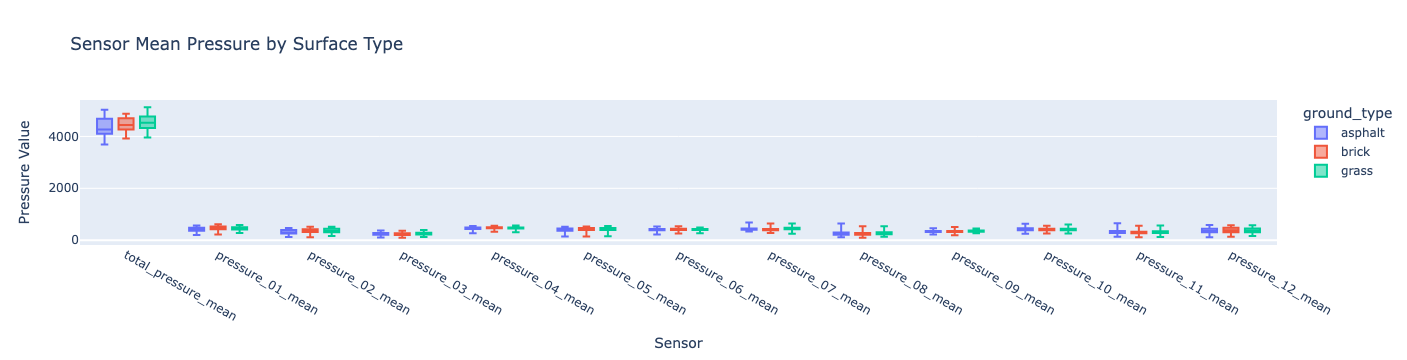

In [16]:
pressure_cols = [c for c in df.columns if "pressure_" in c and "_mean" in c]
print(pressure_cols)

pressure_long = df.melt(
    id_vars=["ground_type"],
    value_vars=pressure_cols,
    var_name="sensor",
    value_name="pressure_value"
)

fig = px.box(
    pressure_long,
    x="sensor",
    y="pressure_value",
    color="ground_type",
    title="Sensor Mean Pressure by Surface Type",
    points=False
)

fig.update_layout(
    xaxis_title="Sensor",
    yaxis_title="Pressure Value"
)

fig.show()

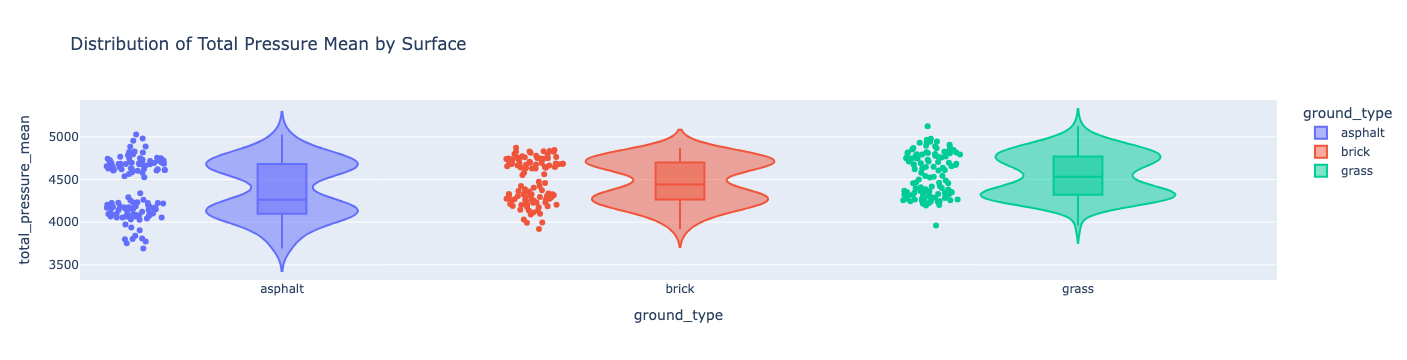

In [17]:
fig = px.violin(
    df,
    x="ground_type",
    y="total_pressure_mean",
    color="ground_type",
    box=True,
    points="all",
    title="Distribution of Total Pressure Mean by Surface"
)

fig.show()

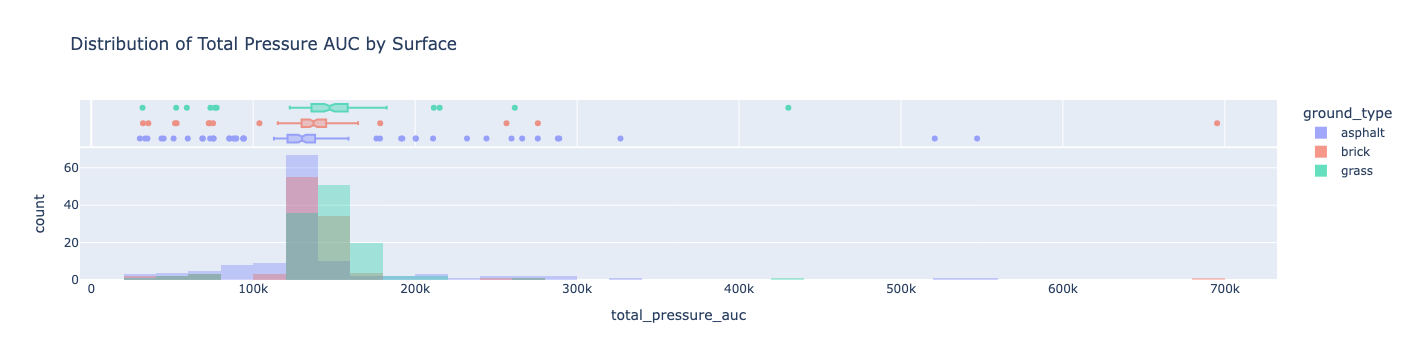

In [18]:
fig = px.histogram(
    df,
    x="total_pressure_auc",
    color="ground_type",
    barmode="overlay",
    marginal="box",
    nbins=40,
    title="Distribution of Total Pressure AUC by Surface"
)

fig.update_traces(opacity=0.6)
fig.show()

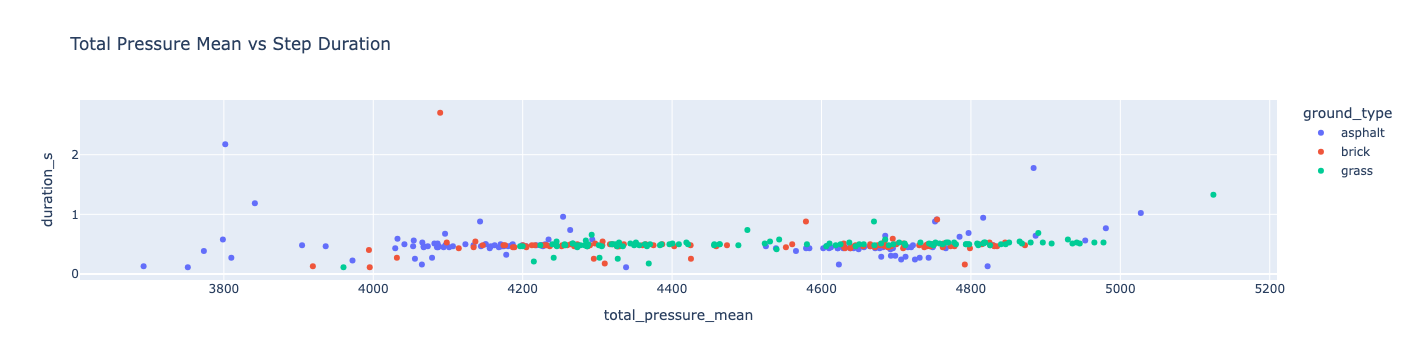

In [19]:
fig = px.scatter(
    df,
    x="total_pressure_mean",
    y="duration_s",
    color="ground_type",
    title="Total Pressure Mean vs Step Duration",
    hover_data=df.columns
)

fig.show()

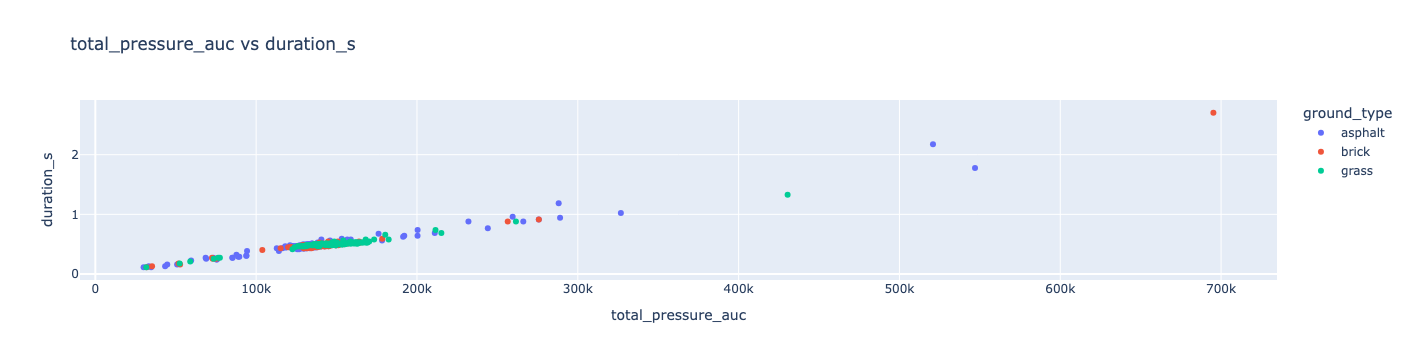

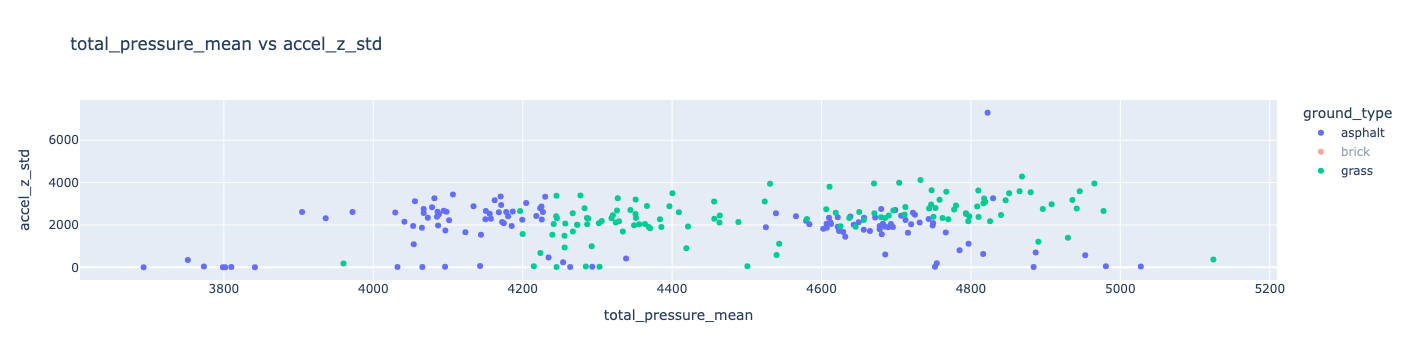

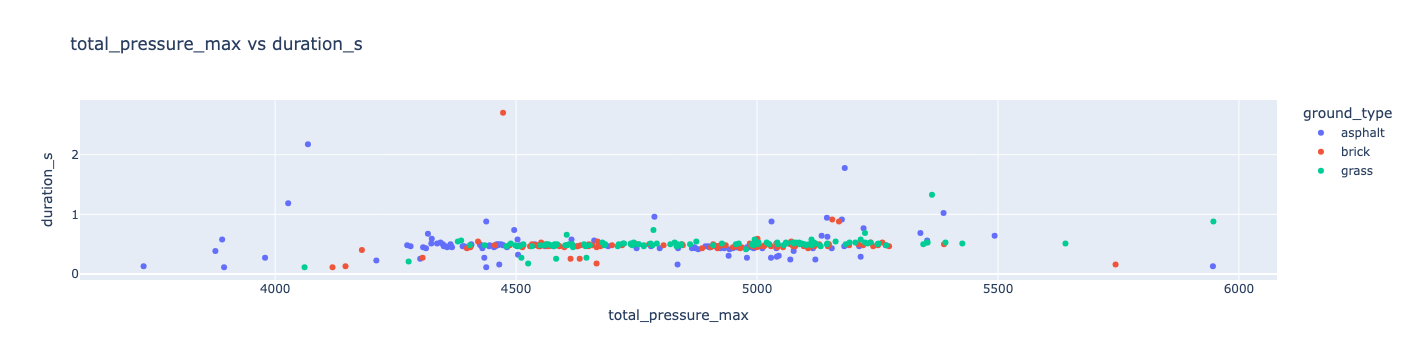

In [20]:
feature_pairs = [
    ("total_pressure_auc", "duration_s"),
    ("total_pressure_mean", "accel_z_std"),
    ("total_pressure_max", "duration_s")
]

for xcol, ycol in feature_pairs:
    fig = px.scatter(
        df,
        x=xcol,
        y=ycol,
        color="ground_type",
        title=f"{xcol} vs {ycol}",
        hover_data=df.columns
    )
    fig.show()

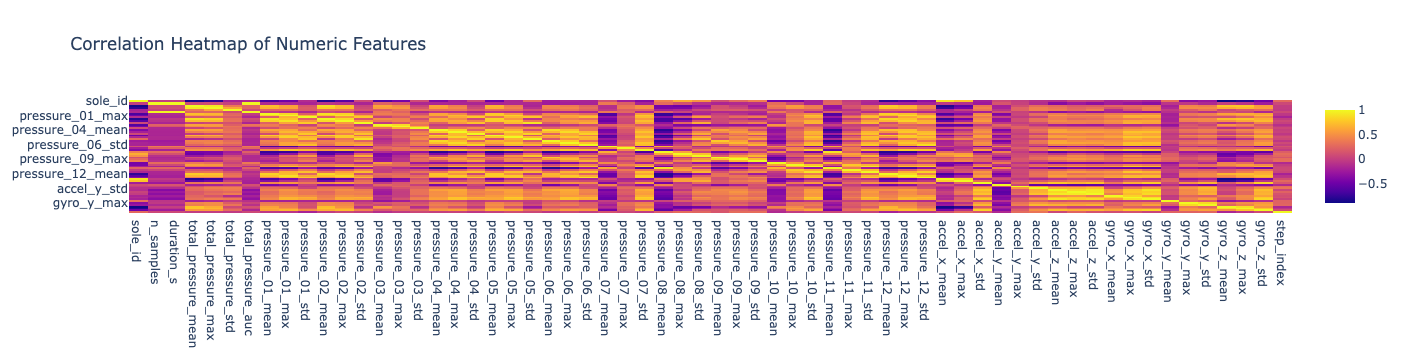

In [21]:
numeric_df = df.select_dtypes(include="number")
corr = numeric_df.corr()

fig = px.imshow(
    corr,
    text_auto=".2f",
    aspect="auto",
    title="Correlation Heatmap of Numeric Features"
)

fig.show()

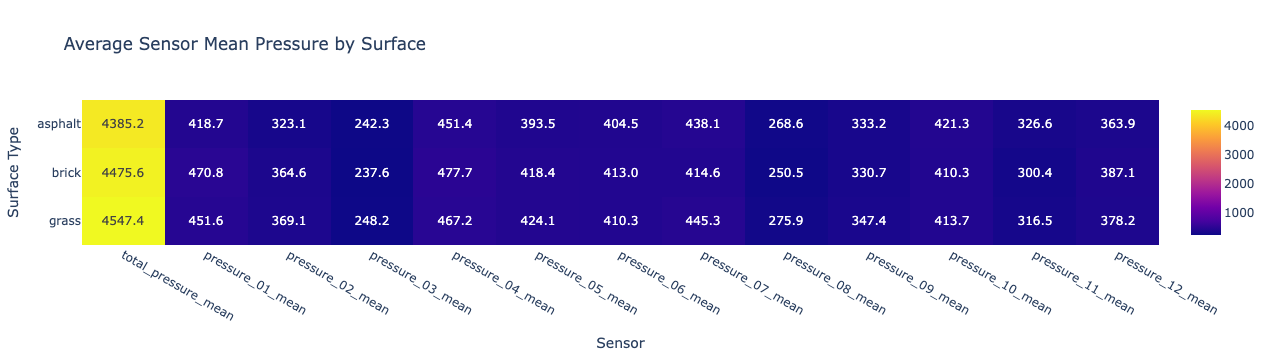

In [22]:
sensor_surface_means = df.groupby("ground_type")[pressure_cols].mean()

fig = px.imshow(
    sensor_surface_means,
    text_auto=".1f",
    aspect="auto",
    title="Average Sensor Mean Pressure by Surface"
)

fig.update_layout(
    xaxis_title="Sensor",
    yaxis_title="Surface Type"
)

fig.show()

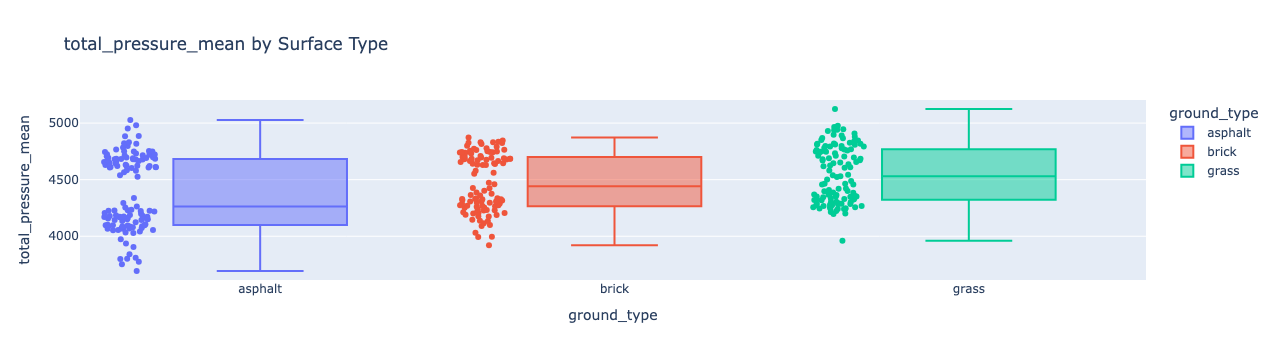

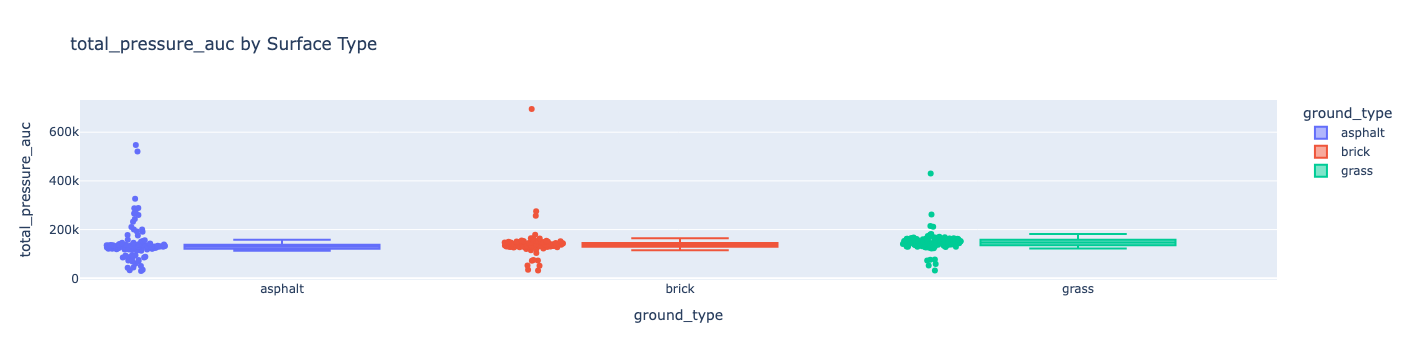

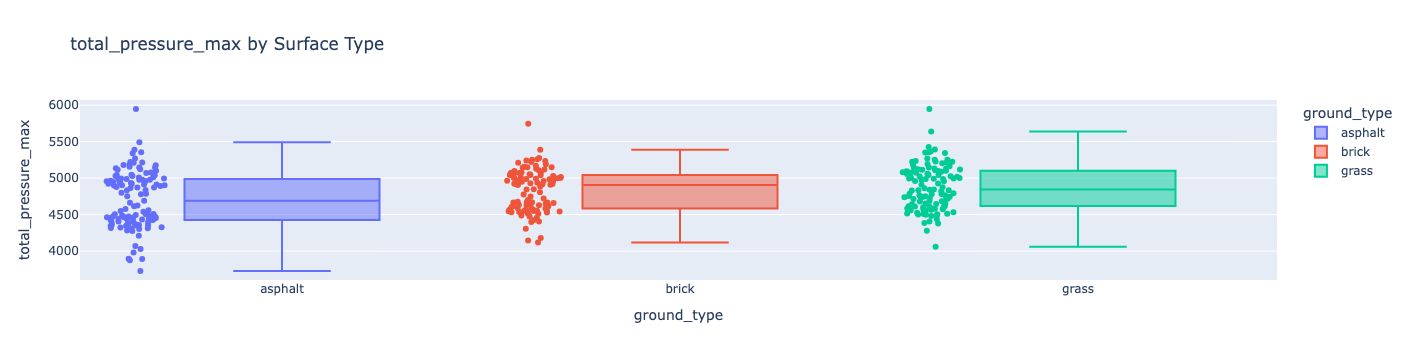

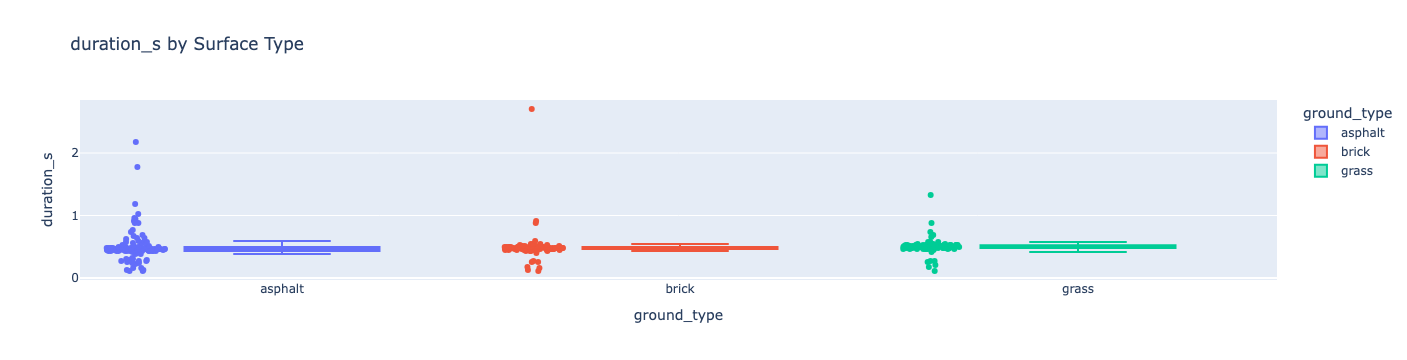

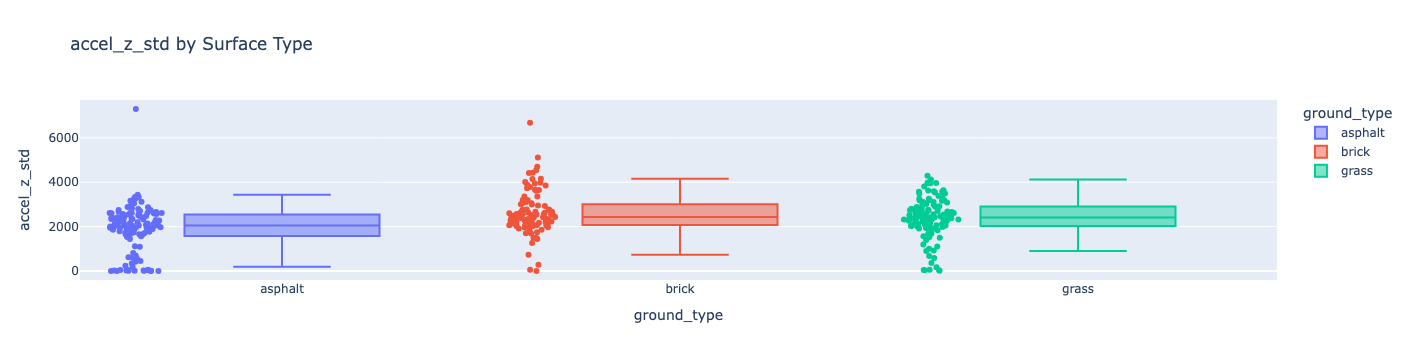

In [23]:
important_features = [
    "total_pressure_mean",
    "total_pressure_auc",
    "total_pressure_max",
    "duration_s",
    "accel_z_std"
]

for col in important_features:
    fig = px.box(
        df,
        x="ground_type",
        y=col,
        color="ground_type",
        points="all",
        title=f"{col} by Surface Type"
    )
    fig.show()